<a href="https://colab.research.google.com/github/amiegirl/3MTT-Nigeria-Internship-Projects/blob/main/module_1_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aminat Owodunni
# Fellow ID: FE/23/64106641
# Cohort 3


# Mini Project: Perform Multiple Linear Regression

## Overview
This project focuses on using multiple linear regression to analyze the relationship between sales and various marketing promotion strategies. By leveraging multiple independent variables, such as TV, social media, radio, and influencer promotions, we aim to build a predictive model that estimates sales based on these factors. This project will cover the complete data science pipeline, including data exploration, preprocessing, model building, evaluation, and interpretation.

## Objective
Develop a multiple linear regression model to predict sales based on marketing promotion data. The project will involve exploring the dataset, selecting relevant independent variables, fitting the model, checking assumptions, and interpreting the results to provide actionable insights.

## Learning Outcomes
1. Understand the concept of multiple linear regression and its applications.
2. Learn to preprocess and explore data for regression analysis.
3. Gain experience in fitting and evaluating a multiple linear regression model.
4. Check and validate regression assumptions.
5. Interpret model coefficients and communicate results to stakeholders.

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


## Step 1: Define the Problem
### Task:
Understand the problem and its real-world implications. The goal is to predict sales based on various marketing promotion strategies, which can help the business optimize its marketing efforts and allocate resources effectively.

### Mini-task:
Write a brief paragraph on how predicting sales using multiple linear regression can benefit the business.

---

## Step 2: Data Collection
### Task:
Collect the dataset required for building the regression model. The dataset used in this project is `marketing_sales_data.csv`, which contains information about TV, social media, radio, and influencer promotions, along with sales data.

### Mini-task:
Load the dataset and inspect the first few rows to understand its structure.

#### Hint:
Use the `pandas` library to load the dataset and display the first five rows.

```python
import pandas as pd

# Load the dataset
data = pd.read_csv('marketing_sales_data.csv')

# Display the first five rows
### YOUR CODE HERE ###
```

---

In [2]:
# Import Data Files from Google Drive

import requests
import pandas as pd
from io import StringIO
def read_gd(sharingurl):
    file_id = sharingurl.split('/')[-2]
    download_url='https://drive.google.com/uc?export=download&id=' + file_id
    url = requests.get(download_url).text
    csv_raw = StringIO(url)
    return csv_raw

url = "https://drive.google.com/file/d/1WChLou3qt_JaPjYLZBMHJ8WxSssQ-enL/view?usp=drive_link"
gdd = read_gd(url)

df = pd.read_csv(gdd)

# Display the first five rows
df.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


## Step 3: Exploratory Data Analysis (EDA)
### Task:
Analyze the dataset to understand the distribution of variables, identify relationships between variables, and prepare the data for modeling.

### Mini-task:
Create a pairplot to visualize the relationships between continuous variables in the dataset.

#### Hint:
Use `seaborn.pairplot()` to create a pairplot of the continuous variables.

```python
import seaborn as sns

# Create a pairplot of the continuous variables
### YOUR CODE HERE ###
```

---

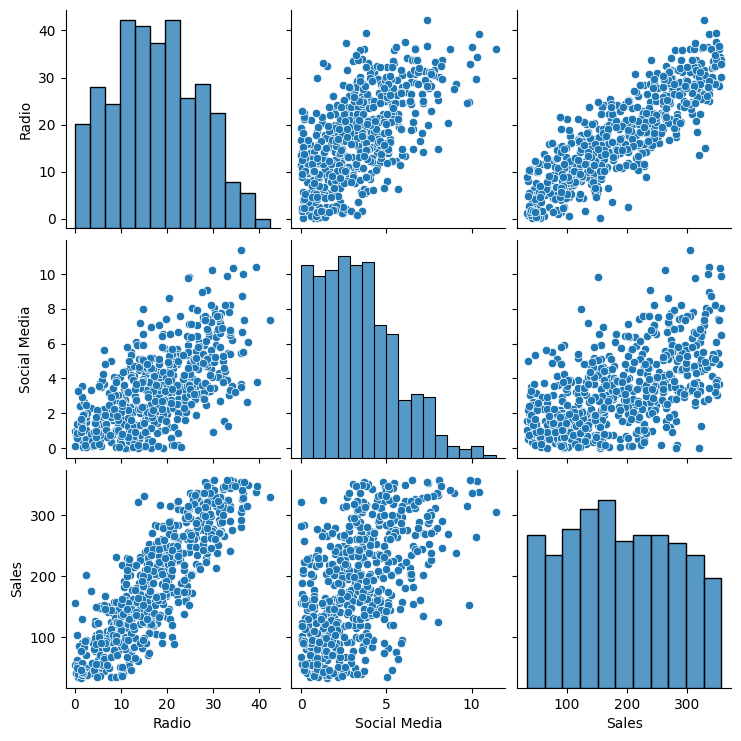

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pairplot of the continuous variables
sns.pairplot(df)
plt.show()



## Step 4: Data Preparation
### Task:
Prepare the data for regression analysis by handling missing values, encoding categorical variables, and splitting the data into training and testing sets.

### Mini-task:
Drop rows with missing values and encode categorical variables if necessary.

#### Hint:
Use `data.dropna()` to remove rows with missing values and `pd.get_dummies()` to encode categorical variables.

```python
# Drop rows with missing values
### YOUR CODE HERE ###

# Encode categorical variables (if needed)
### YOUR CODE HERE ###
```

---

In [4]:
# Drop rows with missing values
df.dropna(inplace=True)

In [5]:
# Encode categorical variables
categorical_cols = ['TV', 'Influencer']

df_encoded = pd.get_dummies(df, columns=categorical_cols, dtype=int)


In [6]:
df_encoded.head()

,Radio,Social Media,Sales,TV_High,TV_Low,TV_Medium,Influencer_Macro,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,3.518070,2.293790,55.261284,0,1,0,0,0,1,0
1,7.756876,2.572287,67.574904,0,1,0,0,1,0,0
2,20.348988,1.227180,272.250108,1,0,0,0,0,1,0
3,20.108487,2.728374,195.102176,0,0,1,0,1,0,0
4,31.653200,7.776978,273.960377,1,0,0,0,0,0,1


## Step 5: Model Building
### Task:
Fit a multiple linear regression model to predict sales using the selected independent variables.

### Mini-task:
Define the OLS formula and fit the model using the `statsmodels` library.

#### Hint:
Use `statsmodels.formula.api.ols()` to define the model and fit it to the data.

```python
import statsmodels.formula.api as smf

# Define the OLS formula
### YOUR CODE HERE ###

# Fit the model
### YOUR CODE HERE ###

# Display the model summary
### YOUR CODE HERE ###
```

---

In [7]:
# Rename 'Social Media' column to Social_Media

df_encoded = df_encoded.rename(columns={'Social Media': 'Social_Media'})


In [8]:
import statsmodels.formula.api as smf

# Define the OLS formula
formula = 'Sales ~ Radio + Social_Media + TV_High + TV_Low + TV_Medium + Influencer_Macro + Influencer_Mega + Influencer_Micro + Influencer_Nano'

# Fit the model
model = smf.ols(formula, data=df_encoded).fit()

# Display the model summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     760.4
Date:                Sat, 05 Apr 2025   Prob (F-statistic):          1.82e-282
Time:                        14:39:27   Log-Likelihood:                -2713.4
No. Observations:                 572   AIC:                             5443.
Df Residuals:                     564   BIC:                             5478.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           89.8828      2.563  

## Step 6: Model Evaluation
### Task:
Evaluate the model by checking the regression assumptions, including linearity, independence, normality, constant variance, and multicollinearity.

### Mini-task:
Create scatterplots to check the linearity assumption and calculate the residuals to check the normality assumption.

#### Hint:
Use `seaborn.scatterplot()` to create scatterplots and `statsmodels.qqplot()` to check the normality of residuals.

```python
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Create scatterplots for linearity
### YOUR CODE HERE ###

# Calculate residuals and create a Q-Q plot
### YOUR CODE HERE ###
```

---

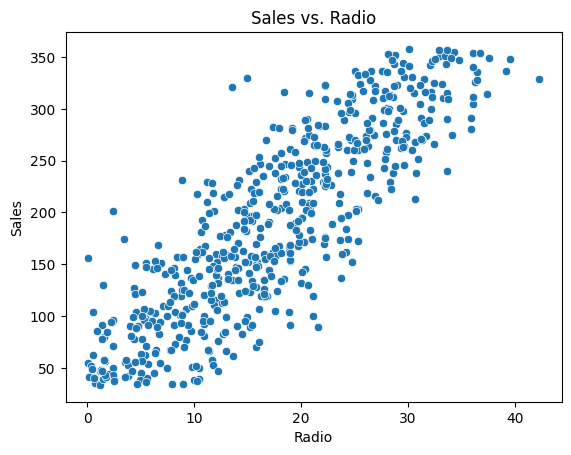

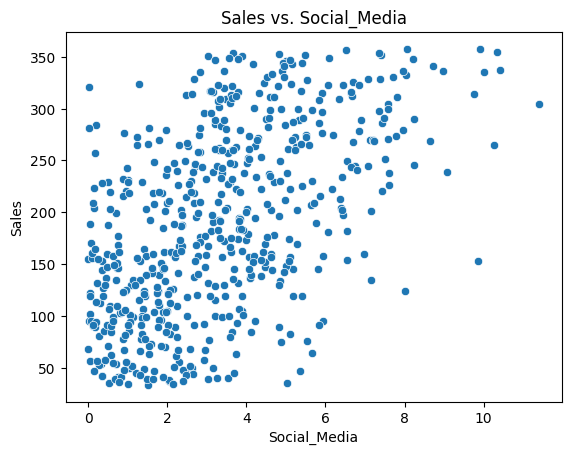

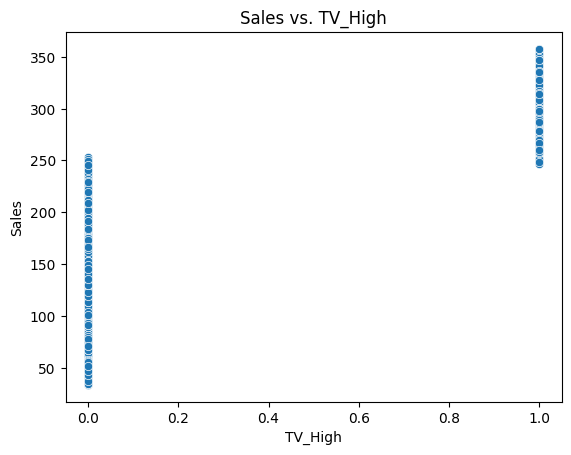

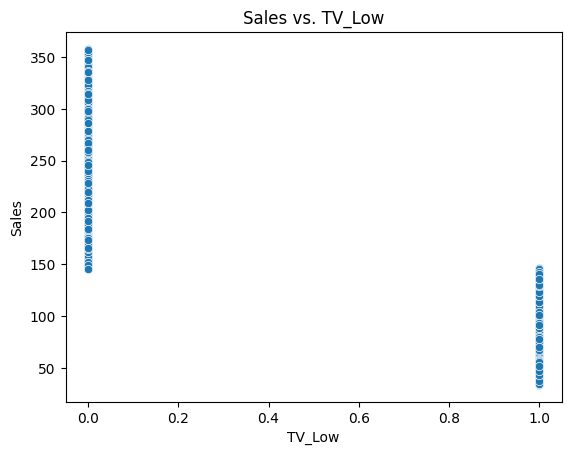

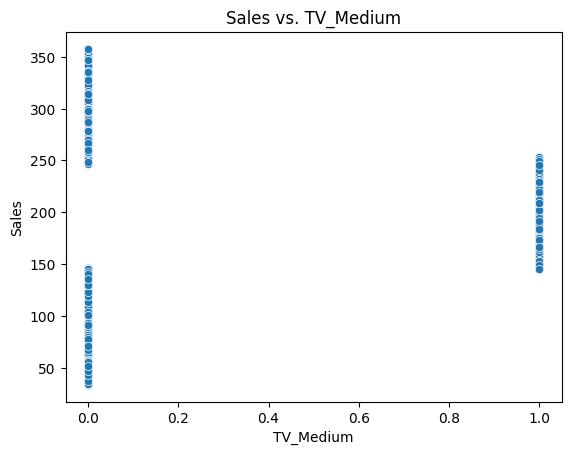

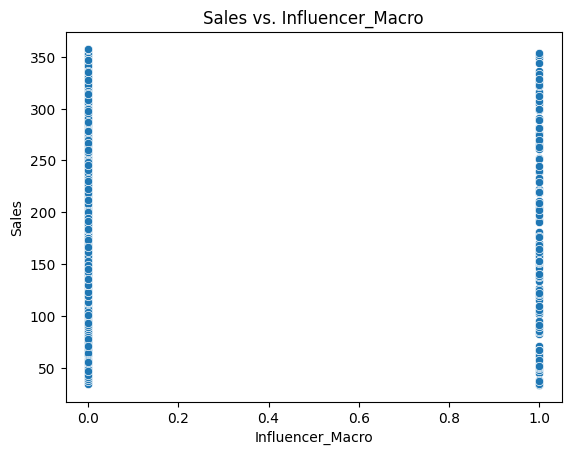

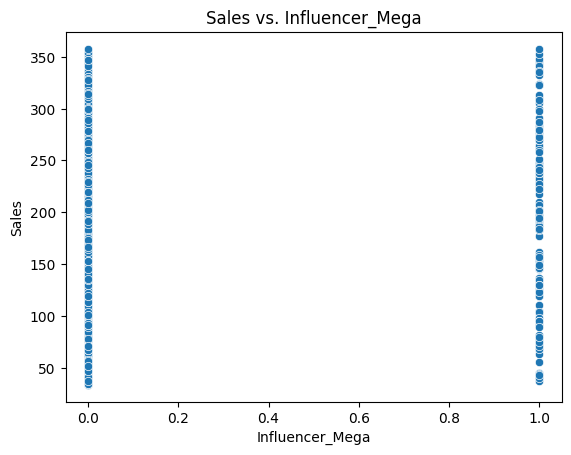

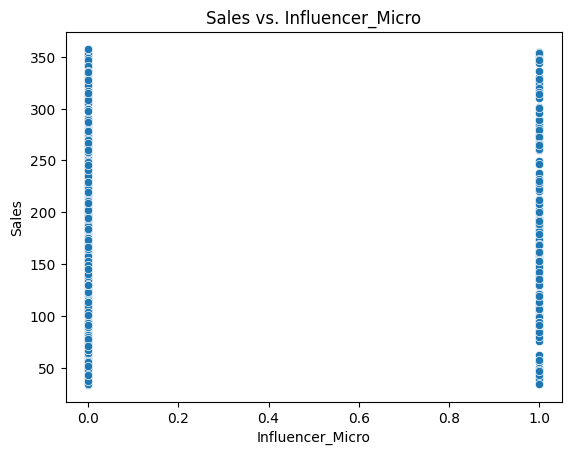

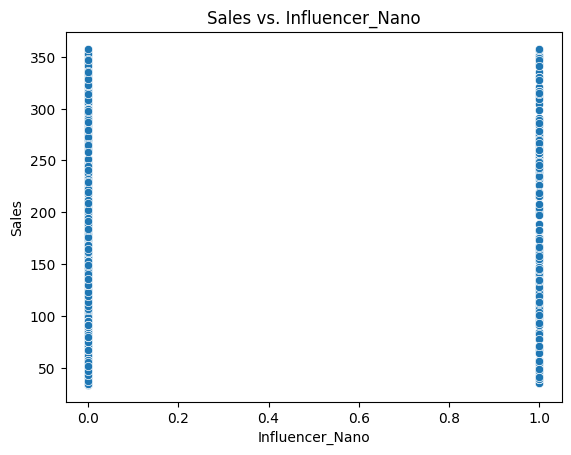

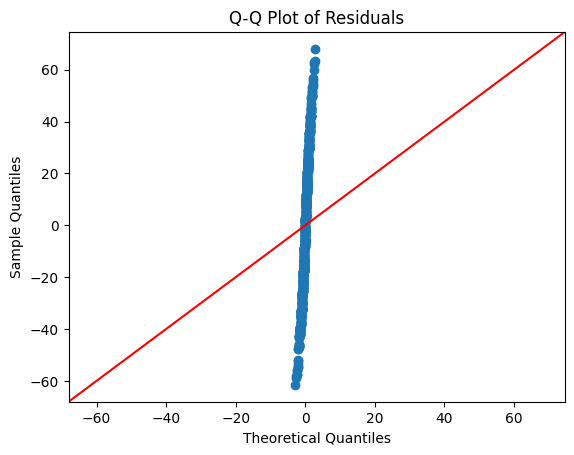

In [9]:
import statsmodels.api as sm

# Create scatterplots for linearity
for col in ['Radio', 'Social_Media', 'TV_High', 'TV_Low', 'TV_Medium', 'Influencer_Macro', 'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']:
    plt.figure()
    sns.scatterplot(x=df_encoded[col], y=df_encoded['Sales'])
    plt.title(f'Sales vs. {col}')
    plt.xlabel(col)
    plt.ylabel('Sales')
    plt.show()

# Calculate residuals and create a Q-Q plot
residuals = model.resid
fig = sm.qqplot(residuals, line='45')
plt.title('Q-Q Plot of Residuals')
plt.show()



## Step 7: Results and Interpretation
### Task:
Interpret the model results, including the R-squared value, coefficients, and their statistical significance.

### Mini-task:
Display the model summary and interpret the coefficients.

#### Hint:
Use `model.summary()` to display the model results and interpret the coefficients.

```python
# Display the model summary
### YOUR CODE HERE ###

# Interpret the coefficients
### YOUR CODE HERE ###
```

---

In [10]:
# Display the model summary
print(model.summary())

# Interpret the coefficients
print("\n Interpretation of Coefficients:")
for coef_name, coef_value in model.params.items():
    p_value = model.pvalues[model.params.index.get_loc(coef_name)]
    if coef_name != 'Intercept':  # Skip the intercept
        print(f"{coef_name}: {coef_value:.2f} (p-value: {p_value:.3f})")

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     760.4
Date:                Sat, 05 Apr 2025   Prob (F-statistic):          1.82e-282
Time:                        14:39:32   Log-Likelihood:                -2713.4
No. Observations:                 572   AIC:                             5443.
Df Residuals:                     564   BIC:                             5478.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           89.8828      2.563  

<ipython-input-10-92f05145cff6>:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = model.pvalues[model.params.index.get_loc(coef_name)]


## Considerations
**What are some key takeaways you learned from this project?**
- Reflect on the importance of checking regression assumptions and interpreting model coefficients.
- Consider how the model's insights can be used to optimize marketing strategies.

**How would you share your findings with a team?**
- Prepare a presentation with visualizations and key metrics.
- Discuss the impact of different marketing strategies on sales.

**What would you share with and recommend to stakeholders?**
- Highlight the key factors that contribute most to sales.
- Recommend strategies to optimize marketing efforts based on the model's insights.

# Overall Model Performance
**R-squared** = 0.904..
This means 90.4% of the variability in Sales. That's very high, indicating a strong fit.<br>
**F-statistic** = 760.4, **p-value (Prob F)** = 1.82e-282. This tests whether at least one predictor variable has a statistically significant effect on the outcome. The very small p-value confirms that your model is statistically significant overall.

# Coefficients & Interpretation#
Variable --- Coefficient	--- P-value --- Interpretation
---
**Intercept** | 89.88 | 0.000 | Baseline Sales when all variables = 0<br>
**Radio**	|2.97	| 0.000	| Each additional unit spent on Radio increases Sales by ~2.97 units.<br>
**Social_Media** |  -0.14  |  0.837	| Not significant (p > 0.05) — no meaningful impact on Sales.<br>
**TV_High**	| 106.68 | 0.000	| High TV budget boosts sales significantly.<br>
**TV_Low** |  -47.89	| 0.000	| Low TV budget hurts sales.<br>
**TV_Medium** | 31.09	| 0.000	| Medium TV budget increases Sales, but less than High TV budget.<br>
**Influencer_Macro** |  20.91	| 0.000	| Working with macro influencers significantly increases sales by ~21 units.<br>
**Influencer_Mega**	| 23.41	| 0.000	| Mega influencers drive slightly higher Sales than Macro influencers.<br>
**Influencer_Micro**  | 23.85	| 0.000	| Micro also has a strong positive effect.<br>
**Influencer_Nano** | 21.71	| 0.000	| Nano influencers are similarly effective,  but slightly less than Mega/Micro.<br>

# Visualization of Key Metrics
**1. The scatter plot below shows the relationship between Sales and Radio.**

The points form an upward trend, suggesting that higher spending on Radio is associated with higher Sales. This aligns with the OLS regression coefficient for Radio (2.97, p-value = 0.000), confirming a statistically significant positive effect.
The pattern is roughly linear, meaning an increase in Radio advertising generally leads to a proportional increase in Sales.
A few points stand far from the general trend, which could be unusual cases or special conditions affecting sales.

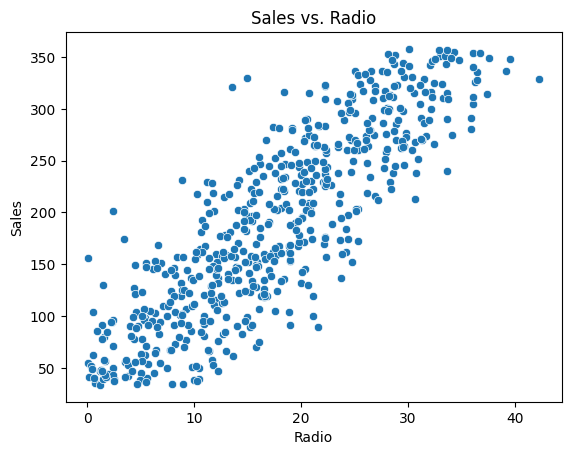
<br>
<br>
**2.The scatter plot shows the relationship between Sales and Social Media spending.**<br>
 The points does not show a clear upward or downward trend. Sales appear widely scattered across different levels of Social_Media spending. This supports the OLS regression result, where Social_Media had a coefficient of -0.1391 with a high p-value (0.837) → not statistically significant. High Variability between Sales values and all levels of Social_Media spending suggests that Social_Media spending alone does not strongly predict Sales.<br>
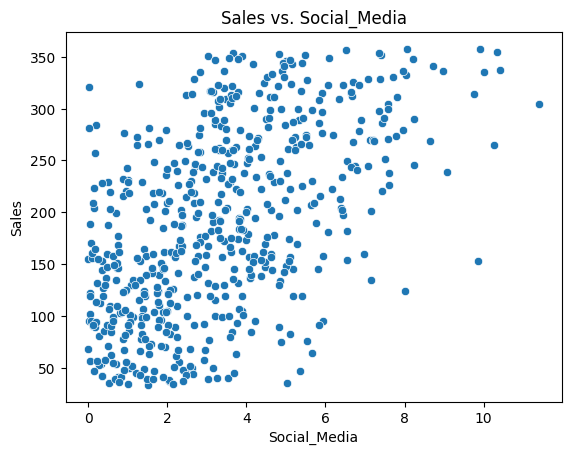

**3. Sales Distribution across TV Categories**.<br>
High TV budgets show the most variability in sales (some campaigns perform exceptionally well, others underperform). Low TV budgets are more consistent but yield minimal sales. The graphs validate the OLS findings. TV_High had a large positive coefficient (+106.68), matching the bar/box plot trends. TV_Low had a negative coefficient (−47.89), reflecting its low sales in the graphs

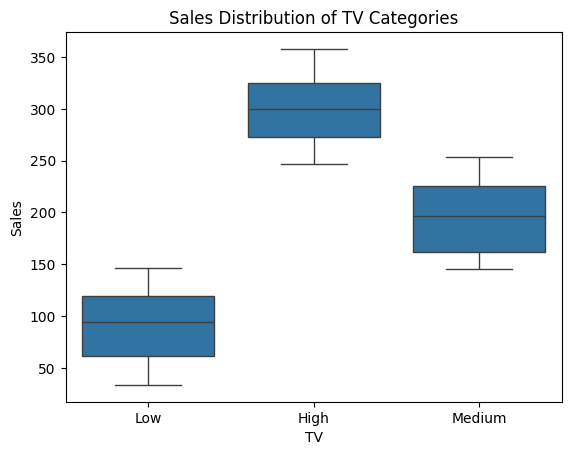

In [11]:
# Sales Distribution across TV Categories
sns.boxplot(x='TV', y='Sales', data=df)
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('Sales Distribution of TV Categories');

**4. Sales Distribution across Influencer Categories.**<br>
Micro and Mega: Shows Wide interquartile ranges (IQRs), indicating high variability in sales outcomes. These influencers can drive exceptional results.<br>
Nano and Macro: Narrower IQRs, suggesting more consistent but modest sales impact.<br>
The plot supports the OLS coefficients:
Micro (Coeff: +23.85): Highest sales impact, matching its top median in the plot.
Mega (Coeff: +23.41): Close second, aligning with its high median.
Nano (Coeff: +21.71) and Macro (Coeff: +20.91): Lower medians in the plot reflect their smaller coefficients.<br>
Micro-influencers often have higher engagement rates than Mega/Macro influencers, driving better conversion despite smaller reach.


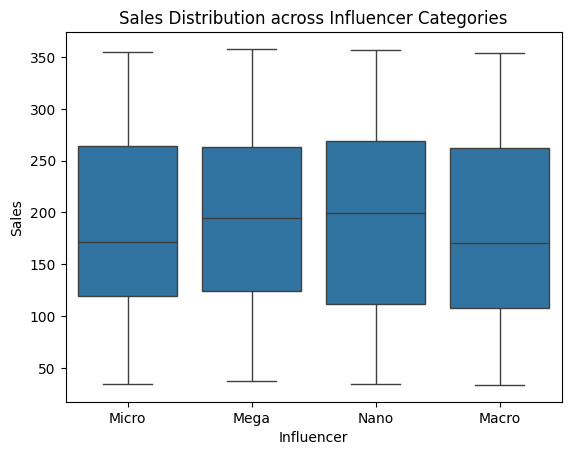

In [12]:
# Sales Distribution across Influencer Categories
sns.boxplot(x='Influencer', y='Sales', data=df)
plt.xlabel('Influencer')
plt.ylabel('Sales')
plt.title('Sales Distribution across Influencer Categories');


# Actionable Insights
1. Social Media has no significant effect on Sales
2. Radio is an important predictor of Sales.
3. TV Advertising Matters a Lot. High TV spend has  the biggest impact(**+106.68 Sales**) suggests that TV is a major driver of Sales.
4. Mega, Micro, Macro, and Nano influencers all significantly improve Sales. Micro & Mega influencers are the most effective.

# Recommendation
1. Increasing Radio ad spend will likely boost sales, but not perfectly.
2. Invest in high TV budgets for maximum sales impact, but monitor for outliers. Low/medium budgets are less risky but generate lower returns.
3.
* Prioritize Micro/Mega Influencers: Allocate more budget to Micro (highest median) and Mega (consistent highs) for maximum ROI.
* Mitigate Risk for Micro/Mega: Investigate outlier campaigns (e.g., poor audience alignment or timing) to reduce variability.
* Use Nano/Macro for Stability, if consistency is critical (e.g., baseline sales). These tiers offer predictable but lower returns.